# Extension: galaxies that are only in one sample

This notebook demonstrates the *partial sample membership* extension (full write-up in the [README](README.md#extension-galaxies-absent-from-a-sample)).

In a real survey the lens and source samples are not the same galaxies. Sources reach higher redshift than lenses, so lots of galaxies show up as **sources with no lens bin**, and the nearest galaxies can be **lenses with no source bin**.

We handle this with one simple idea: give each label an extra value, **"absent"** (written as `-1` in the catalogue), meaning "this galaxy is not in that sample." A galaxy stays in the catalogue as long as it is in at least one sample.

That is essentially the only change. The recipe is exactly as before, with a bit of extra bookkeeping:

- We still only have target $n(z)$ curves for the **real** bins — there is no target for the "absent" group.
- When we check that a lens bin reproduces its target, the mixture now includes one extra piece: the galaxies in that lens bin that are **not** sources. The same goes for source bins (galaxies that are not lenses).
- These extra **border** groups — lens-only and source-only galaxies — have no target of their own. The flow simply fills them in as "whatever is left over" to make the real-bin targets add up.

The pay-off: once trained, the flow gives a sensible redshift to **every** galaxy, including the high-redshift sources that never had a lens bin.

*(Under the hood, "absent" is just stored as one more category, so a flow with `L+1` lens slots and `S+1` source slots covers everything; the real bins keep their usual indices and "absent" is the last slot.)*

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt

import mcra

torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__)

torch 2.12.0


## 1. A universe with partial membership

`mcra.make_partial_demo()` builds a parent population and two **membership curves** that depend on redshift: how likely a galaxy is to be in the lens sample (high nearby, falling off far away) and in the source sample (rising with distance). Inside each sample the galaxies are split into 3 bins by smooth redshift windows — lenses low, sources reaching higher. A galaxy is kept if it lands in at least one sample.

The label statistics we read off the catalogue now include the "absent" category: for each lens bin we record what fraction of its galaxies are **not** sources, and for each source bin what fraction are **not** lenses (these are the last column of `p_s_given_l` and the last row of `p_l_given_s`).

In [2]:
data = mcra.make_partial_demo()

print(f"{data.n_lens} lens bins, {data.n_source} source bins (absent slot = {data.lens_absent_slot})")
print("lens bin mean redshifts  :", np.round([t.mean for t in data.lens_targets], 3))
print("source bin mean redshifts:", np.round([t.mean for t in data.source_targets], 3))
print("\np(i_S = absent | i_L = l):", np.round(data.p_s_given_l[:, -1], 3), " (lens bins with no source)")
print("p(i_L = absent | i_S = s):", np.round(data.p_l_given_s[-1, :], 3), " (source bins with no lens)")
print("\np(i_S = b | i_L = l), last column = absent:")
print(np.round(data.p_s_given_l, 3))

3 lens bins, 3 source bins (absent slot = 3)
lens bin mean redshifts  : [0.325 0.473 0.648]
source bin mean redshifts: [0.501 0.794 1.254]

p(i_S = absent | i_L = l): [0.466 0.271 0.121]  (lens bins with no source)
p(i_L = absent | i_S = s): [0.185 0.672 0.973]  (source bins with no lens)

p(i_S = b | i_L = l), last column = absent:
[[0.514 0.02  0.    0.466]
 [0.601 0.125 0.003 0.271]
 [0.425 0.404 0.05  0.121]]


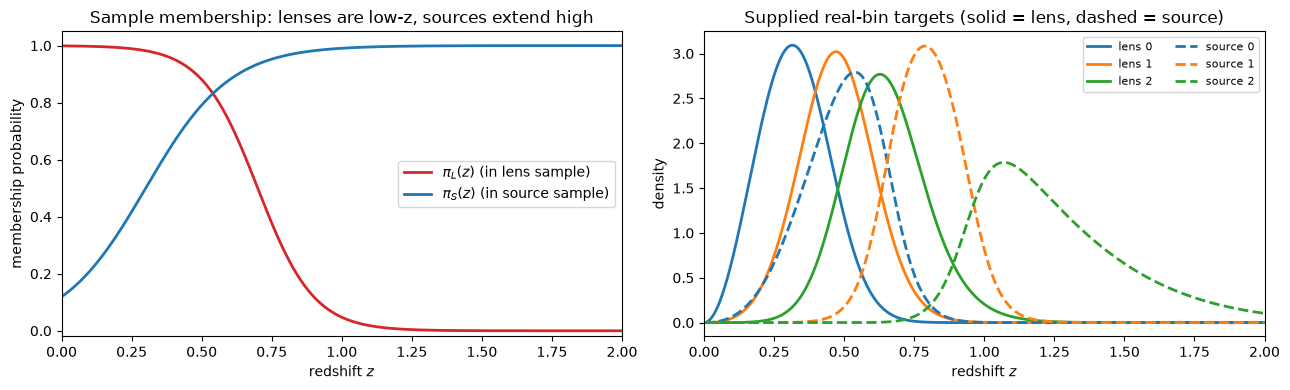

In [3]:
zg = data.z_grid
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Membership probabilities vs redshift.
ax = axes[0]
ax.plot(zg, data.pi_lens(zg), "C3", lw=2, label="$\\pi_L(z)$ (in lens sample)")
ax.plot(zg, data.pi_source(zg), "C0", lw=2, label="$\\pi_S(z)$ (in source sample)")
ax.set_xlim(0, 2.0); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("redshift $z$"); ax.set_ylabel("membership probability")
ax.set_title("Sample membership: lenses are low-z, sources extend high")
ax.legend()

# Supplied real-bin targets: lenses (solid) below sources (dashed).
ax = axes[1]
for l in range(data.n_lens):
    ax.plot(zg, data.lens_targets[l].pdf(zg), color=f"C{l}", lw=2, label=f"lens {l}")
for s in range(data.n_source):
    ax.plot(zg, data.source_targets[s].pdf(zg), color=f"C{s}", lw=2, ls="--", label=f"source {s}")
ax.set_xlim(0, 2.0)
ax.set_xlabel("redshift $z$"); ax.set_ylabel("density")
ax.set_title("Supplied real-bin targets (solid = lens, dashed = source)")
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
plt.show()

## 2. Train the flow

The flow is built with one extra slot per label so it has somewhere to put the "absent" group. Training only pushes on the real bins (those are the only ones with a target); the lens-only and source-only border groups get filled in automatically, because they appear inside the real-bin mixtures.

In [4]:
model = mcra.ConditionalRedshiftFlow(
    data.n_lens + 1, data.n_source + 1,   # +1 slot each for the absent token
    z_mean=data.z_mean, z_std=data.z_std,
    bins=8, transforms=3, hidden_features=[64, 64],
)

config = mcra.TrainConfig(
    steps=2500, batch_size=512, lr=2e-3,
    device="cpu", seed=0, log_every=250,
)
history = mcra.train(model, data, config)

step     0 | loss   3.4842 | lens   1.8832 | source   1.6010


step   250 | loss  -2.9159 | lens  -1.7803 | source  -1.1357


step   500 | loss  -2.8492 | lens  -1.7235 | source  -1.1257


step   750 | loss  -2.9036 | lens  -1.7582 | source  -1.1453


step  1000 | loss  -2.9124 | lens  -1.7674 | source  -1.1450


...

step  1500 | loss  -2.8411 | lens  -1.7565 | source  -1.0846


step  1750 | loss  -2.7701 | lens  -1.6479 | source  -1.1223


step  2000 | loss  -2.9295 | lens  -1.8075 | source  -1.1220


step  2250 | loss  -2.9119 | lens  -1.7175 | source  -1.1944


step  2499 | loss  -2.8512 | lens  -1.7782 | source  -1.0730


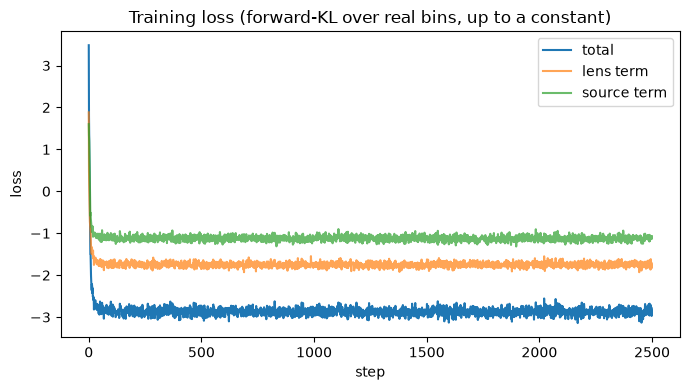

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["loss"], label="total")
ax.plot(history["lens_kl"], label="lens term", alpha=0.7)
ax.plot(history["source_kl"], label="source term", alpha=0.7)
ax.set_xlabel("step"); ax.set_ylabel("loss")
ax.set_title("Training loss (forward-KL over real bins, up to a constant)")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Validation — real-bin marginals

For each real lens and source bin, the redshift distribution the model implies (mixing in the right fractions, including the "absent" piece) should match the supplied target.

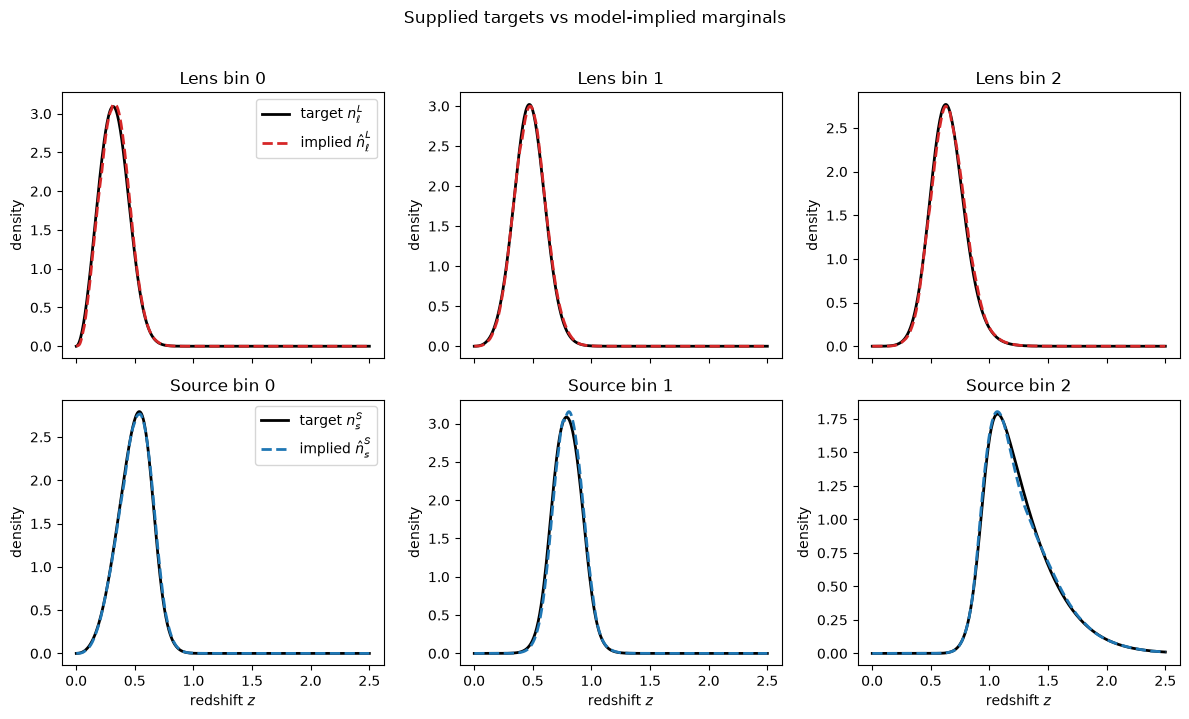

Per-real-bin agreement between supplied target and model-implied marginal:

               bin0  bin1  bin2
lens   KL    : 0.0025  0.0009  0.0015
source KL    : 0.0008  0.0029  0.0021


In [6]:
mcra.plot_partial_marginals(model, data)
plt.show()

metrics = mcra.marginal_metrics(model, data)
print("Per-real-bin agreement between supplied target and model-implied marginal:\n")
print("              ", "  ".join(f"bin{i}" for i in range(data.n_lens)))
print("lens   KL    :", "  ".join(f"{x:.4f}" for x in metrics["lens_kl"]))
print("source KL    :", "  ".join(f"{x:.4f}" for x in metrics["source_kl"]))

## 4. The full grid of conditionals, including the border

Below are the learned redshift distributions for every combination of labels, including the extra "absent" row and column. The bottom row (source-only galaxies) and the right column (lens-only galaxies) are the **border** cells: single-sample galaxies with no target of their own. The flow infers them purely as the leftover needed to make the real-bin targets add up — yet they still come out close to the truth. The bottom-right corner (galaxies in neither sample) is never observed, so it is left blank.

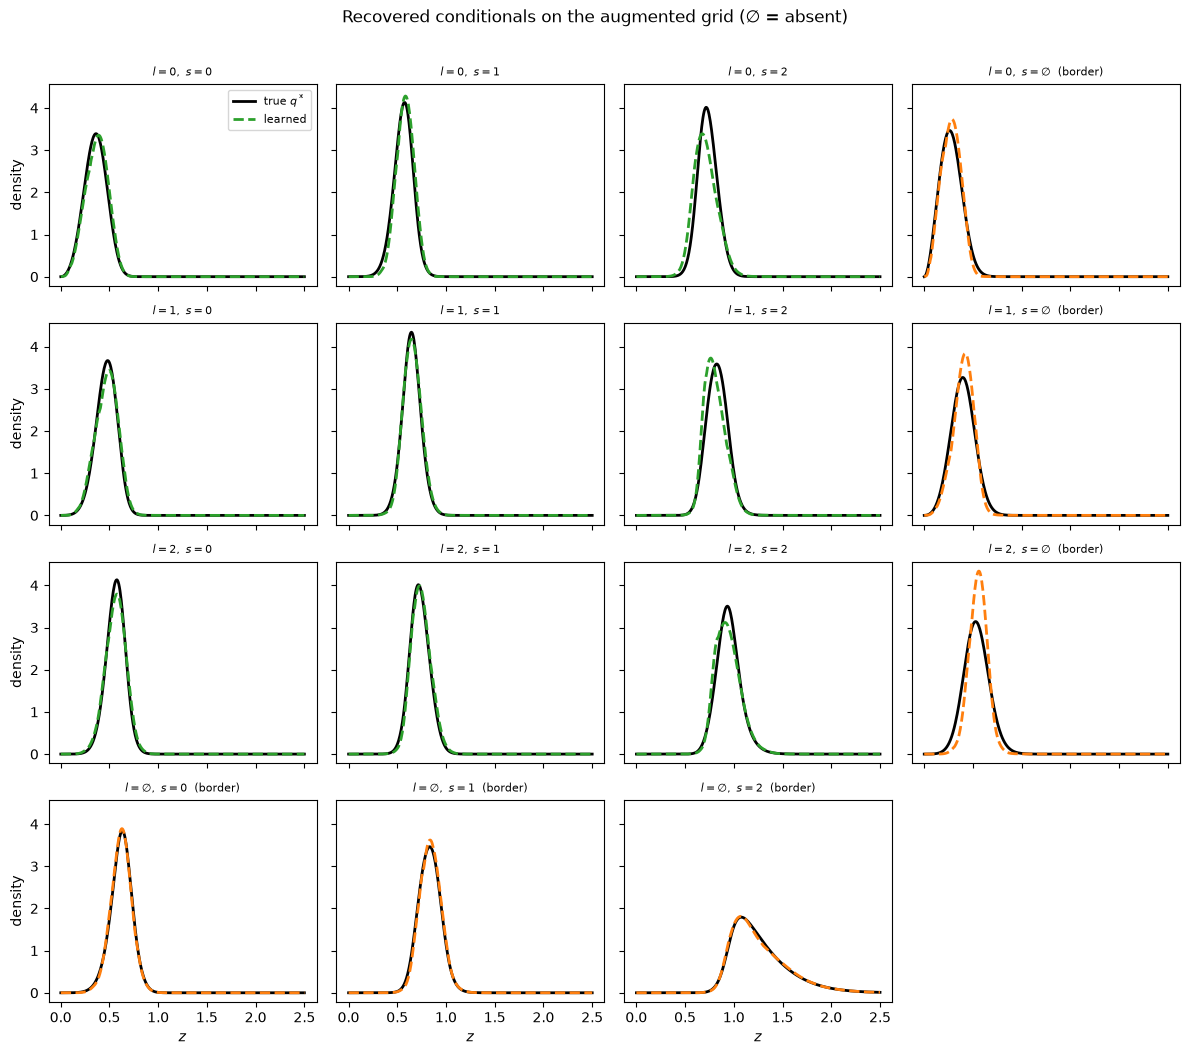

In [7]:
mcra.plot_partial_conditionals(model, data)
plt.show()

## 5. Assign redshifts to a partial catalogue

We draw a catalogue in which many galaxies belong to only one sample (labelled `-1` for the sample they are missing from), give each one a redshift drawn from its own distribution — including the **single-sample** galaxies, which use the inferred border distributions — and check that each real bin still reproduces its supplied $n(z)$.

catalogue: 393,518 galaxies | both=124,338  source-only=225,887  lens-only=43,293


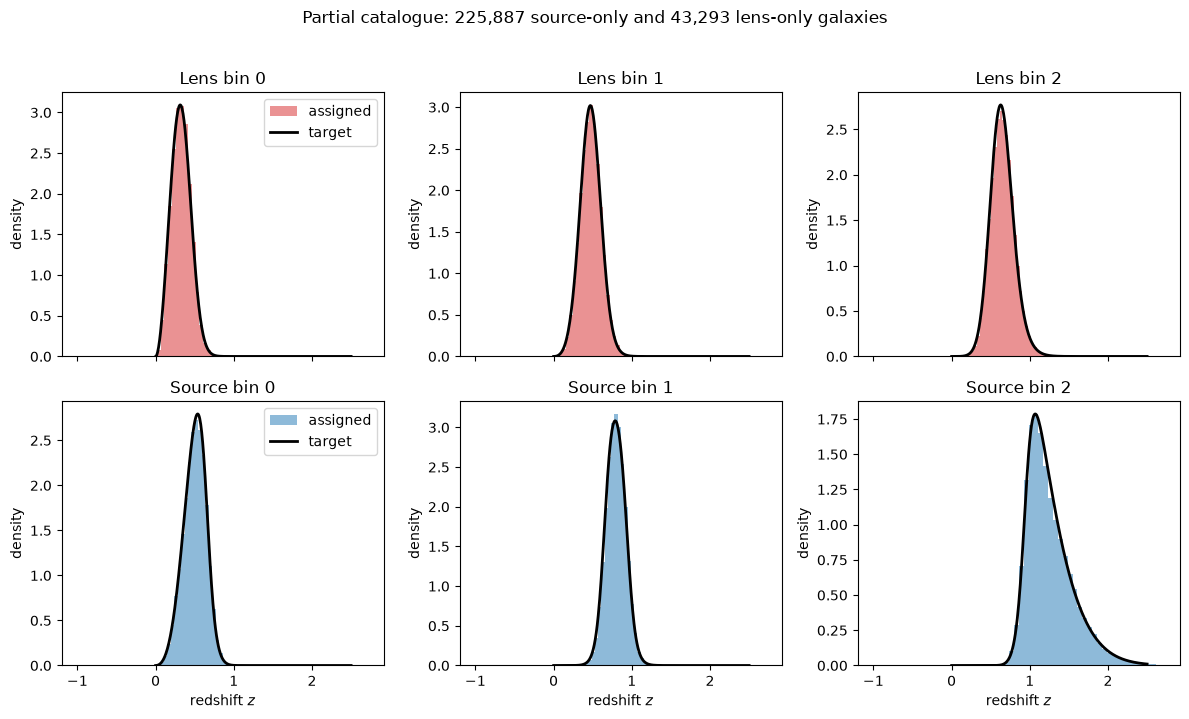

In [8]:
i_l, i_s, _ = mcra.sample_partial_catalogue(data, n=400_000, seed=1)
n_both = int(np.sum((i_l >= 0) & (i_s >= 0)))
n_src_only = int(np.sum((i_l < 0) & (i_s >= 0)))
n_lens_only = int(np.sum((i_s < 0) & (i_l >= 0)))
print(f"catalogue: {len(i_l):,} galaxies | both={n_both:,}  source-only={n_src_only:,}  lens-only={n_lens_only:,}")

mcra.plot_partial_catalogue(model, data, n=400_000, seed=1)
plt.show()